In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
# Path to the original evidence files
data_path = Path("data_raw")

# Load all supplied datasets
assets = pd.read_csv(data_path / "ot_asset_inventory.csv")
users = pd.read_csv(data_path / "ot_user_directory.csv")
auth = pd.read_csv(data_path / "ot_authentication_logs.csv")
dns = pd.read_csv(data_path / "ot_dns_logs.csv")
firewall = pd.read_csv(data_path / "ot_firewall_logs.csv")
flow_train = pd.read_csv(data_path / "ot_network_flow_training.csv")
flow_investigation = pd.read_csv(data_path / "ot_network_flow_investigation.csv")
dictionary = pd.read_csv(data_path / "data_dictionary.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [3]:
# Display dataset sizes and column names
datasets = {
    "Asset Inventory": assets,
    "User Directory": users,
    "Authentication Logs": auth,
    "DNS Logs": dns,
    "Firewall Logs": firewall,
    "Network Flow Training": flow_train,
    "Network Flow Investigation": flow_investigation,
    "Data Dictionary": dictionary
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    print("Column names:")
    print(df.columns.tolist())


Asset Inventory
Rows: 12, Columns: 7
Column names:
['asset_id', 'hostname', 'ip_address', 'asset_type', 'business_unit', 'criticality', 'owner']

User Directory
Rows: 6, Columns: 8
Column names:
['user_id', 'full_name', 'department', 'role', 'assigned_host', 'normal_start', 'normal_end', 'privileged']

Authentication Logs
Rows: 248, Columns: 9
Column names:
['event_id', 'timestamp', 'user_id', 'source_ip', 'destination_host', 'logon_type', 'result', 'failure_reason', 'process']

DNS Logs
Rows: 632, Columns: 8
Column names:
['event_id', 'timestamp', 'client_ip', 'query_name', 'query_type', 'response_code', 'response_ip', 'ttl']

Firewall Logs
Rows: 1408, Columns: 13
Column names:
['event_id', 'timestamp', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'protocol', 'action', 'bytes_out', 'bytes_in', 'duration_sec', 'rule_name', 'country']

Network Flow Training
Rows: 2400, Columns: 18
Column names:
['flow_id', 'timestamp', 'src_ip', 'dst_ip', 'dst_port', 'protocol', 'duration_sec', 'src_byt

In [4]:
# B1 - Data quality and structure checks

for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(f"Rows: {len(df)}")
    print(f"Columns: {len(df.columns)}")

    print("\nData types:")
    print(df.dtypes)

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:")
    print(df.duplicated().sum())


Asset Inventory
Rows: 12
Columns: 7

Data types:
asset_id         str
hostname         str
ip_address       str
asset_type       str
business_unit    str
criticality      str
owner            str
dtype: object

Missing values:
asset_id         0
hostname         0
ip_address       0
asset_type       0
business_unit    0
criticality      0
owner            0
dtype: int64

Duplicate rows:
0

User Directory
Rows: 6
Columns: 8

Data types:
user_id          str
full_name        str
department       str
role             str
assigned_host    str
normal_start     str
normal_end       str
privileged       str
dtype: object

Missing values:
user_id          0
full_name        0
department       0
role             0
assigned_host    0
normal_start     0
normal_end       0
privileged       0
dtype: int64

Duplicate rows:
0

Authentication Logs
Rows: 248
Columns: 9

Data types:
event_id            str
timestamp           str
user_id             str
source_ip           str
destination_host    str
l

In [5]:
# Convert timestamp columns to a consistent datetime format

for name, df in datasets.items():
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        print(f"{name}: timestamp converted to {df['timestamp'].dtype}")

Authentication Logs: timestamp converted to datetime64[us]
DNS Logs: timestamp converted to datetime64[us]
Firewall Logs: timestamp converted to datetime64[us]
Network Flow Training: timestamp converted to datetime64[us]
Network Flow Investigation: timestamp converted to datetime64[us]


In [6]:
# Verify timestamp conversion by displaying sample values

for name, df in datasets.items():
    if "timestamp" in df.columns:
        print(f"\n{name}")
        print(df["timestamp"].head())


Authentication Logs
0   2026-08-10 00:10:19
1   2026-08-10 06:02:15
2   2026-08-10 06:19:25
3   2026-08-10 06:48:55
4   2026-08-10 06:50:21
Name: timestamp, dtype: datetime64[us]

DNS Logs
0   2026-08-10 01:18:46
1   2026-08-10 01:23:50
2   2026-08-10 01:25:18
3   2026-08-10 01:57:00
4   2026-08-10 02:00:10
Name: timestamp, dtype: datetime64[us]

Firewall Logs
0   2026-08-10 00:03:56
1   2026-08-10 00:21:53
2   2026-08-10 00:24:00
3   2026-08-10 00:24:36
4   2026-08-10 00:36:45
Name: timestamp, dtype: datetime64[us]

Network Flow Training
0   2026-08-16 18:05:12
1   2026-08-10 22:46:01
2   2026-08-13 18:00:34
3   2026-08-14 21:00:37
4   2026-08-11 17:26:45
Name: timestamp, dtype: datetime64[us]

Network Flow Investigation
0   2026-08-10 00:15:57
1   2026-08-10 00:27:36
2   2026-08-10 01:22:04
3   2026-08-10 01:41:42
4   2026-08-10 01:44:46
Name: timestamp, dtype: datetime64[us]


In [7]:
# Create derived time-based variables

for name, df in datasets.items():
    if "timestamp" in df.columns:
        df["hour"] = df["timestamp"].dt.hour
        df["is_weekend"] = df["timestamp"].dt.dayofweek >= 5
        df["off_hours"] = (df["hour"] < 6) | (df["hour"] >= 20)

print("Derived time variables created successfully.")

Derived time variables created successfully.


In [8]:
# Create total network traffic volume for firewall events

firewall["total_bytes"] = firewall["bytes_out"] + firewall["bytes_in"]

print("Firewall total_bytes variable created successfully.")

Firewall total_bytes variable created successfully.


In [9]:
auth[["timestamp", "hour", "is_weekend", "off_hours"]].head()

,timestamp,hour,is_weekend,off_hours
0,2026-08-10 00:10:19,0,False,True
1,2026-08-10 06:02:15,6,False,False
2,2026-08-10 06:19:25,6,False,False
3,2026-08-10 06:48:55,6,False,False
4,2026-08-10 06:50:21,6,False,False


In [10]:


for name, df in datasets.items():
    print(f"\n{name}")
    print(f"Rows: {len(df)}")
    print(f"Missing values: {df.isnull().sum().sum()}")
    print(f"Duplicate rows: {df.duplicated().sum()}")

    if "event_id" in df.columns:
        print(f"Duplicate event IDs: {df['event_id'].duplicated().sum()}")

    if "timestamp" in df.columns:
        print(f"Invalid timestamps (NaT): {df['timestamp'].isna().sum()}")


Asset Inventory
Rows: 12
Missing values: 0
Duplicate rows: 0

User Directory
Rows: 6
Missing values: 0
Duplicate rows: 0

Authentication Logs
Rows: 248
Missing values: 223
Duplicate rows: 0
Duplicate event IDs: 0
Invalid timestamps (NaT): 0

DNS Logs
Rows: 632
Missing values: 0
Duplicate rows: 0
Duplicate event IDs: 0
Invalid timestamps (NaT): 0

Firewall Logs
Rows: 1408
Missing values: 228
Duplicate rows: 0
Duplicate event IDs: 0
Invalid timestamps (NaT): 0

Network Flow Training
Rows: 2400
Missing values: 0
Duplicate rows: 0
Invalid timestamps (NaT): 0

Network Flow Investigation
Rows: 466
Missing values: 0
Duplicate rows: 0
Invalid timestamps (NaT): 0

Data Dictionary
Rows: 19
Missing values: 0
Duplicate rows: 0


In [11]:
# Inspect missing values in the authentication logs by column

print("Authentication Logs - Missing Values by Column")
print(auth.isnull().sum())

Authentication Logs - Missing Values by Column
event_id              0
timestamp             0
user_id               0
source_ip             0
destination_host      0
logon_type            0
result                0
failure_reason      223
process               0
hour                  0
is_weekend            0
off_hours             0
dtype: int64


In [12]:
# Check whether missing failure reasons correspond to successful logins

auth.groupby("result")["failure_reason"].agg(
    total_events="size",
    missing_failure_reason=lambda x: x.isna().sum()
)

,total_events,missing_failure_reason
result,,
FAILURE,25,0
SUCCESS,223,223


In [13]:
# B2 - Authentication successes and failures by hour

auth_by_hour = (
    auth.groupby(["hour", "result"])
        .size()
        .unstack(fill_value=0)
)

auth_by_hour

result,FAILURE,SUCCESS
hour,,
0,0,7
1,6,2
2,0,1
6,1,13
7,2,23
8,4,21
9,1,18
10,1,15
11,1,12


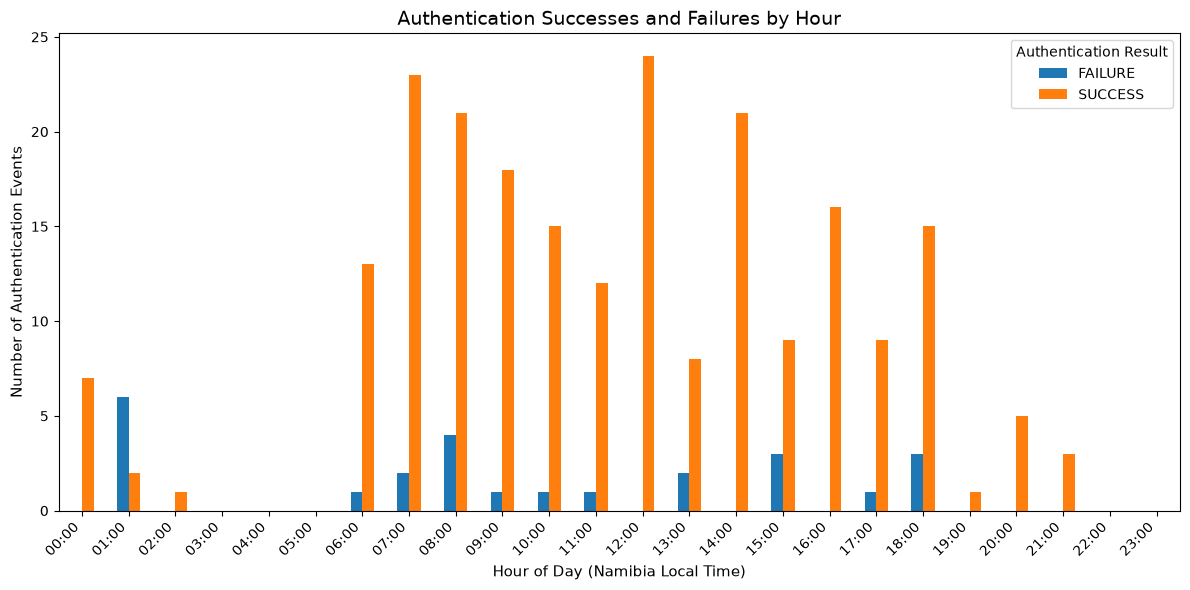

In [14]:
# Visualisation 1 - Authentication successes and failures by hour

# Include all 24 hours, even hours with no events
auth_plot = auth_by_hour.reindex(range(24), fill_value=0)

ax = auth_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

# Proper graph labelling
ax.set_title(
    "Authentication Successes and Failures by Hour",
    fontsize=14
)

ax.set_xlabel(
    "Hour of Day (Namibia Local Time)",
    fontsize=11
)

ax.set_ylabel(
    "Number of Authentication Events",
    fontsize=11
)

# Make hours easier to understand
ax.set_xticklabels(
    [f"{hour:02d}:00" for hour in range(24)],
    rotation=45,
    ha="right"
)

ax.legend(
    title="Authentication Result"
)

plt.tight_layout()
plt.show()

In [15]:
# Investigate authentication activity occurring during the 01:00 hour

auth_1am = auth[auth["hour"] == 1].copy()

auth_1am[
    [
        "event_id",
        "timestamp",
        "user_id",
        "source_ip",
        "destination_host",
        "logon_type",
        "result",
        "failure_reason",
        "process"
    ]
].sort_values("timestamp")

,event_id,timestamp,user_id,source_ip,destination_host,logon_type,result,failure_reason,process
175,A00176,2026-08-15 01:41:02,nshikongo,10.14.7.23,AD-CORE-01,RemoteInteractive,FAILURE,Bad password,mstsc.exe
176,A00177,2026-08-15 01:41:14,nshikongo,10.14.7.23,AD-CORE-01,RemoteInteractive,FAILURE,Bad password,mstsc.exe
177,A00178,2026-08-15 01:41:29,nshikongo,10.14.7.23,AD-CORE-01,RemoteInteractive,FAILURE,Bad password,mstsc.exe
178,A00179,2026-08-15 01:41:47,nshikongo,10.14.7.23,AD-CORE-01,RemoteInteractive,FAILURE,Bad password,mstsc.exe
179,A00180,2026-08-15 01:42:03,nshikongo,10.14.7.23,AD-CORE-01,RemoteInteractive,FAILURE,Bad password,mstsc.exe
180,A00181,2026-08-15 01:42:19,nshikongo,10.14.7.23,AD-CORE-01,RemoteInteractive,FAILURE,Bad password,mstsc.exe
181,A00182,2026-08-15 01:42:38,nshikongo,10.14.7.23,AD-CORE-01,RemoteInteractive,SUCCESS,NaN,mstsc.exe
182,A00183,2026-08-15 01:52:07,nshikongo,10.14.7.23,AD-CORE-01,Network,SUCCESS,NaN,powershell.exe


In [16]:
# Identify the user and assets associated with the 01:00 authentication anomaly

print("USER DIRECTORY RECORD")
display(users[users["user_id"] == "nshikongo"])

print("\nSOURCE IP ASSET RECORD")
display(assets[assets["ip_address"] == "10.14.7.23"])

print("\nDESTINATION HOST ASSET RECORD")
display(assets[assets["hostname"] == "AD-CORE-01"])

USER DIRECTORY RECORD


,user_id,full_name,department,role,assigned_host,normal_start,normal_end,privileged
0,nshikongo,Nangula Shikongo,Finance,Revenue Analyst,WKST-FIN-023,07:00,18:00,No



SOURCE IP ASSET RECORD


,asset_id,hostname,ip_address,asset_type,business_unit,criticality,owner
7,OT-A008,WKST-FIN-023,10.14.7.23,Workstation,Finance,Medium,N. Shikongo



DESTINATION HOST ASSET RECORD


,asset_id,hostname,ip_address,asset_type,business_unit,criticality,owner
0,OT-A001,AD-CORE-01,10.20.1.10,Domain Controller,ICT,Critical,Identity Team


In [17]:
# Map firewall source IPs to asset hostnames

firewall_enriched = firewall.merge(
    assets[["ip_address", "hostname", "business_unit", "criticality"]],
    left_on="src_ip",
    right_on="ip_address",
    how="left"
)

# Calculate total outbound bytes by source host
outbound_by_host = (
    firewall_enriched.groupby(["hostname", "src_ip"])["bytes_out"]
    .sum()
    .sort_values(ascending=False)
)

outbound_by_host

hostname      src_ip    
WKST-FIN-023  10.14.7.23    432178438
WKST-HR-011   10.14.8.11      4137448
WKST-CSR-018  10.14.9.18      4103317
WKST-NOC-004  10.14.5.4       3700787
APP-CRM-01    10.20.9.10      1364307
MAIL-GW-01    10.20.2.15      1179822
Name: bytes_out, dtype: int64

In [18]:
# Examine outbound traffic from the suspicious Finance workstation over time

fin_firewall = firewall_enriched[
    firewall_enriched["hostname"] == "WKST-FIN-023"
].copy()

fin_outbound_hourly = (
    fin_firewall
    .set_index("timestamp")
    .resample("1h")["bytes_out"]
    .sum()
    .sort_values(ascending=False)
)

fin_outbound_hourly.head(10)

timestamp
2026-08-15 02:00:00    426981672
2026-08-12 05:00:00       213109
2026-08-10 06:00:00       182673
2026-08-15 00:00:00       180809
2026-08-13 11:00:00       177828
2026-08-16 04:00:00       149085
2026-08-16 21:00:00       148948
2026-08-15 01:00:00       144722
2026-08-14 21:00:00       137717
2026-08-12 12:00:00       137163
Name: bytes_out, dtype: int64

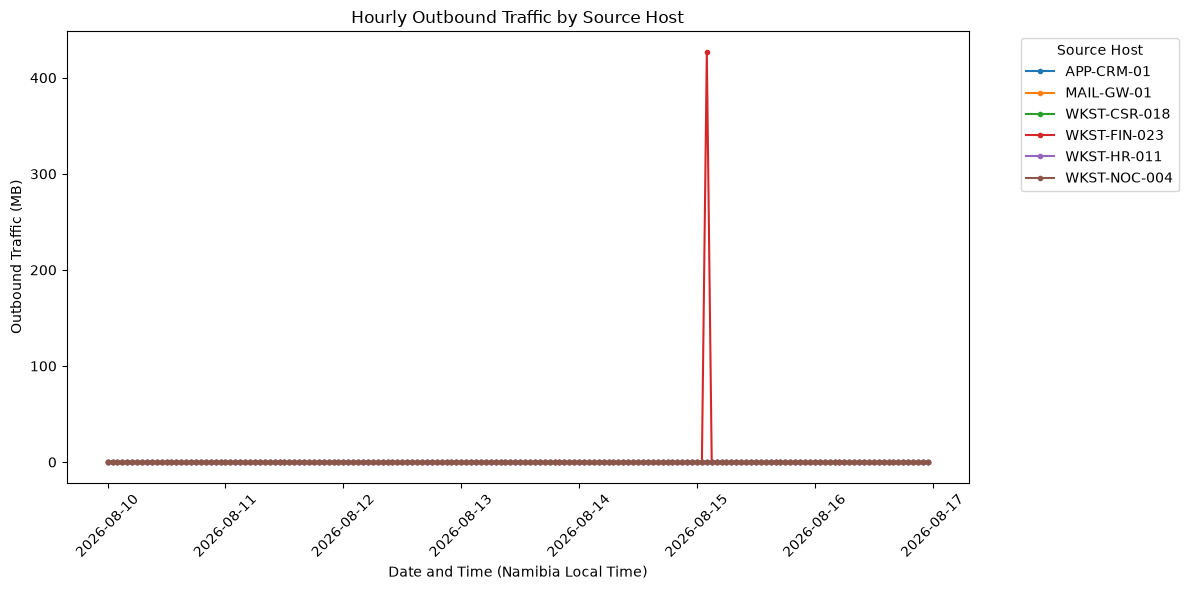

In [19]:
# Visualisation 2 - Outbound traffic by source host and time

# Create hourly outbound totals for each source host
hourly_host_traffic = (
    firewall_enriched
    .set_index("timestamp")
    .groupby("hostname")["bytes_out"]
    .resample("1h")
    .sum()
    .reset_index()
)

# Convert bytes to megabytes for readability
hourly_host_traffic["outbound_mb"] = (
    hourly_host_traffic["bytes_out"] / 1_000_000
)

# Plot each host over time
fig, ax = plt.subplots(figsize=(12, 6))

for hostname, group in hourly_host_traffic.groupby("hostname"):
    ax.plot(
        group["timestamp"],
        group["outbound_mb"],
        marker="o",
        markersize=3,
        label=hostname
    )

ax.set_title("Hourly Outbound Traffic by Source Host")
ax.set_xlabel("Date and Time (Namibia Local Time)")
ax.set_ylabel("Outbound Traffic (MB)")
ax.legend(title="Source Host", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Examine the largest outbound destinations from WKST-FIN-023

fin_destinations = (
    fin_firewall
    .groupby(["dst_ip", "dst_port", "country", "rule_name"])["bytes_out"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fin_destinations.head(10)

,dst_ip,dst_port,country,rule_name,bytes_out
0,45.77.89.11,443,SG,OUTBOUND-WEB,426692125
1,185.125.190.29,80,GB,OUTBOUND-WEB,76466
2,13.107.6.156,443,US,OUTBOUND-WEB,66521
3,142.250.74.14,443,US,OUTBOUND-WEB,65797
4,104.16.132.229,53,US,DNS-OUT,61976
5,140.82.121.4,123,US,NTP-OUT,53321
6,104.16.132.229,80,US,OUTBOUND-WEB,49280
7,104.16.132.229,123,US,NTP-OUT,48682
8,104.16.132.229,443,US,OUTBOUND-WEB,43184
9,20.112.52.29,53,US,DNS-OUT,42699


In [21]:
# Correlate suspicious external IP with DNS activity

dns_target = dns[
    (dns["client_ip"] == "10.14.7.23") &
    (dns["response_ip"] == "45.77.89.11")
][
    [
        "event_id",
        "timestamp",
        "client_ip",
        "query_name",
        "query_type",
        "response_code",
        "response_ip",
        "ttl"
    ]
].sort_values("timestamp")

dns_target

,event_id,timestamp,client_ip,query_name,query_type,response_code,response_ip,ttl
457,D00458,2026-08-15 02:34:04,10.14.7.23,cdn-sync-update.com,A,NOERROR,45.77.89.11,60
458,D00459,2026-08-15 02:39:08,10.14.7.23,cdn-sync-update.com,A,NOERROR,45.77.89.11,60


In [22]:
# Visualisation 3 - Top external destinations by outbound traffic

import ipaddress

# Identify whether an IP address is external/public
def is_external_ip(ip):
    try:
        return not ipaddress.ip_address(ip).is_private
    except ValueError:
        return False

# Keep only traffic destined for external/public IP addresses
firewall_external = firewall[
    firewall["dst_ip"].apply(is_external_ip)
].copy()

# Calculate outbound traffic by destination
top_external = (
    firewall_external
    .groupby(["dst_ip", "country"])["bytes_out"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Convert bytes to MB
top_external["outbound_mb"] = top_external["bytes_out"] / 1_000_000

top_external

,dst_ip,country,bytes_out,outbound_mb
0,45.77.89.11,SG,426692125,426.692125
1,185.125.190.29,GB,1174502,1.174502
2,142.250.74.14,US,1135460,1.135460
3,20.112.52.29,US,1021009,1.021009
4,13.107.6.156,US,951207,0.951207
5,104.16.132.229,US,849192,0.849192
6,140.82.121.4,US,808071,0.808071
7,44.236.72.93,US,746229,0.746229
8,185.199.110.42,NL,4969,0.004969


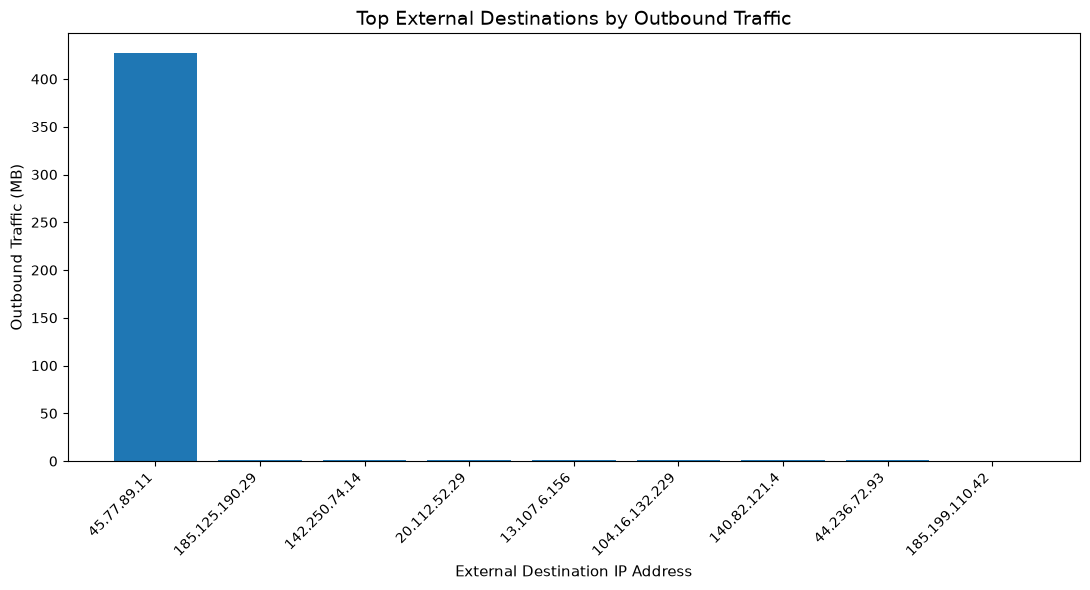

In [23]:
# Visualisation 3 - Top external destinations by outbound traffic

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    top_external["dst_ip"],
    top_external["outbound_mb"]
)

ax.set_title(
    "Top External Destinations by Outbound Traffic",
    fontsize=14
)

ax.set_xlabel(
    "External Destination IP Address",
    fontsize=11
)

ax.set_ylabel(
    "Outbound Traffic (MB)",
    fontsize=11
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [24]:
# B2 - Summary table comparing normal hours and off-hours activity

# Label activity periods
auth["activity_period"] = auth["off_hours"].map({
    False: "Normal hours",
    True: "Off-hours"
})

firewall["activity_period"] = firewall["off_hours"].map({
    False: "Normal hours",
    True: "Off-hours"
})

# Authentication summary
auth_period_summary = auth.groupby("activity_period").agg(
    authentication_events=("event_id", "count"),
    successful_logins=("result", lambda x: (x == "SUCCESS").sum()),
    failed_logins=("result", lambda x: (x == "FAILURE").sum())
)

# Firewall summary
firewall_period_summary = firewall.groupby("activity_period").agg(
    firewall_events=("event_id", "count"),
    outbound_bytes=("bytes_out", "sum")
)

# Combine the two summaries
period_summary = auth_period_summary.join(firewall_period_summary)

# Convert outbound bytes to MB
period_summary["outbound_mb"] = (
    period_summary["outbound_bytes"] / 1_000_000
)

# Calculate percentage of total outbound traffic
period_summary["outbound_percent"] = (
    period_summary["outbound_bytes"]
    / period_summary["outbound_bytes"].sum()
    * 100
)

# Display useful columns
period_summary[
    [
        "authentication_events",
        "successful_logins",
        "failed_logins",
        "firewall_events",
        "outbound_mb",
        "outbound_percent"
    ]
].round(2)

,authentication_events,successful_logins,failed_logins,firewall_events,outbound_mb,outbound_percent
activity_period,,,,,,
Normal hours,224,205,19,780,10.97,2.46
Off-hours,24,18,6,628,435.69,97.54


In [25]:
# B3 - Define a transparent anomaly criterion using the 99th percentile

outbound_threshold = hourly_host_traffic["bytes_out"].quantile(0.99)

print(f"99th percentile threshold: {outbound_threshold:,.0f} bytes")
print(f"99th percentile threshold: {outbound_threshold / 1_000_000:.2f} MB")

99th percentile threshold: 151,853 bytes
99th percentile threshold: 0.15 MB


In [26]:
# Apply the 99th-percentile anomaly criterion

traffic_anomalies = hourly_host_traffic[
    hourly_host_traffic["bytes_out"] > outbound_threshold
].copy()

# Convert bytes to MB for easier interpretation
traffic_anomalies["outbound_mb"] = (
    traffic_anomalies["bytes_out"] / 1_000_000
)

# Show flagged events from largest to smallest
traffic_anomalies[
    ["timestamp", "hostname", "bytes_out", "outbound_mb"]
].sort_values("bytes_out", ascending=False)

,timestamp,hostname,bytes_out,outbound_mb
625,2026-08-15 02:00:00,WKST-FIN-023,426981672,426.981672
556,2026-08-12 05:00:00,WKST-FIN-023,213109,0.213109
697,2026-08-11 02:00:00,WKST-HR-011,201682,0.201682
383,2026-08-12 00:00:00,WKST-CSR-018,190540,0.190540
509,2026-08-10 06:00:00,WKST-FIN-023,182673,0.182673
623,2026-08-15 00:00:00,WKST-FIN-023,180809,0.180809
586,2026-08-13 11:00:00,WKST-FIN-023,177828,0.177828
406,2026-08-12 23:00:00,WKST-CSR-018,172275,0.172275
501,2026-08-16 22:00:00,WKST-CSR-018,168193,0.168193
495,2026-08-16 16:00:00,WKST-CSR-018,159895,0.159895


In [27]:
# Add contextual information to the detected anomalies

traffic_anomalies["hour"] = traffic_anomalies["timestamp"].dt.hour
traffic_anomalies["is_weekend"] = traffic_anomalies["timestamp"].dt.dayofweek >= 5
traffic_anomalies["off_hours"] = (
    (traffic_anomalies["hour"] < 6) |
    (traffic_anomalies["hour"] >= 20)
)

traffic_anomalies[
    [
        "timestamp",
        "hostname",
        "outbound_mb",
        "is_weekend",
        "off_hours"
    ]
].sort_values("outbound_mb", ascending=False)

,timestamp,hostname,outbound_mb,is_weekend,off_hours
625,2026-08-15 02:00:00,WKST-FIN-023,426.981672,True,True
556,2026-08-12 05:00:00,WKST-FIN-023,0.213109,False,True
697,2026-08-11 02:00:00,WKST-HR-011,0.201682,False,True
383,2026-08-12 00:00:00,WKST-CSR-018,0.190540,False,True
509,2026-08-10 06:00:00,WKST-FIN-023,0.182673,False,False
623,2026-08-15 00:00:00,WKST-FIN-023,0.180809,True,True
586,2026-08-13 11:00:00,WKST-FIN-023,0.177828,False,False
406,2026-08-12 23:00:00,WKST-CSR-018,0.172275,False,True
501,2026-08-16 22:00:00,WKST-CSR-018,0.168193,True,True
495,2026-08-16 16:00:00,WKST-CSR-018,0.159895,True,False


In [28]:
# C1 - Extract firewall events associated with the suspicious external destination

suspicious_firewall = firewall[
    (firewall["src_ip"] == "10.14.7.23") &
    (firewall["dst_ip"] == "45.77.89.11")
][
    [
        "event_id",
        "timestamp",
        "src_ip",
        "src_port",
        "dst_ip",
        "dst_port",
        "protocol",
        "action",
        "bytes_out",
        "bytes_in",
        "duration_sec",
        "rule_name",
        "country"
    ]
].sort_values("timestamp")

suspicious_firewall

,event_id,timestamp,src_ip,src_port,dst_ip,dst_port,protocol,action,bytes_out,bytes_in,duration_sec,rule_name,country
1020,F01021,2026-08-15 02:41:19,10.14.7.23,55000,45.77.89.11,443,TCP,ALLOW,22876890,14024,77.18,OUTBOUND-WEB,SG
1021,F01022,2026-08-15 02:42:13,10.14.7.23,55001,45.77.89.11,443,TCP,ALLOW,24759124,12594,55.60,OUTBOUND-WEB,SG
1022,F01023,2026-08-15 02:43:01,10.14.7.23,55002,45.77.89.11,443,TCP,ALLOW,23568850,19701,58.75,OUTBOUND-WEB,SG
1023,F01024,2026-08-15 02:44:10,10.14.7.23,55003,45.77.89.11,443,TCP,ALLOW,20315516,33878,50.56,OUTBOUND-WEB,SG
1024,F01025,2026-08-15 02:45:03,10.14.7.23,55004,45.77.89.11,443,TCP,ALLOW,24224582,15012,89.97,OUTBOUND-WEB,SG
1025,F01026,2026-08-15 02:46:01,10.14.7.23,55005,45.77.89.11,443,TCP,ALLOW,22194332,34772,73.85,OUTBOUND-WEB,SG
1027,F01028,2026-08-15 02:47:00,10.14.7.23,55006,45.77.89.11,443,TCP,ALLOW,26320432,32683,67.26,OUTBOUND-WEB,SG
1028,F01029,2026-08-15 02:48:05,10.14.7.23,55007,45.77.89.11,443,TCP,ALLOW,27855109,17850,62.94,OUTBOUND-WEB,SG
1029,F01030,2026-08-15 02:49:06,10.14.7.23,55008,45.77.89.11,443,TCP,ALLOW,21421414,11196,91.85,OUTBOUND-WEB,SG
1030,F01031,2026-08-15 02:50:06,10.14.7.23,55009,45.77.89.11,443,TCP,ALLOW,25875470,11523,86.95,OUTBOUND-WEB,SG


In [29]:
# C1 - Build a correlated incident timeline

timeline_rows = [
    {
        "event_id": "A00176-A00181",
        "timestamp": "2026-08-15 01:41",
        "source": "Authentication",
        "action_observed": "Six failed RemoteInteractive logons from 10.14.7.23 to AD-CORE-01",
        "interpretation": "Repeated off-hours authentication failures from the Finance workstation."
    },
    {
        "event_id": "A00182",
        "timestamp": "2026-08-15 01:42",
        "source": "Authentication",
        "action_observed": "Successful RemoteInteractive logon to AD-CORE-01",
        "interpretation": "Successful access immediately followed repeated password failures."
    },
    {
        "event_id": "A00183",
        "timestamp": "2026-08-15 01:52",
        "source": "Authentication",
        "action_observed": "Authentication activity associated with powershell.exe",
        "interpretation": "Potential post-authentication command activity requiring correlation."
    },
    {
        "event_id": "D00458",
        "timestamp": "2026-08-15 02:34:04",
        "source": "DNS",
        "action_observed": "cdn-sync-update.com resolved to 45.77.89.11",
        "interpretation": "Finance workstation resolved infrastructure later used for outbound traffic."
    },
    {
        "event_id": "D00459",
        "timestamp": "2026-08-15 02:39:08",
        "source": "DNS",
        "action_observed": "cdn-sync-update.com again resolved to 45.77.89.11",
        "interpretation": "Repeated DNS activity confirms association with the external destination."
    },
    {
        "event_id": "F01021-F01039",
        "timestamp": "2026-08-15 02:41-02:58",
        "source": "Firewall",
        "action_observed": "Repeated TCP/443 connections from 10.14.7.23 to 45.77.89.11 allowed by OUTBOUND-WEB",
        "interpretation": "Sustained outbound transfer of approximately 426.69 MB to the associated external infrastructure."
    }
]

timeline = pd.DataFrame(timeline_rows)

timeline

,event_id,timestamp,source,action_observed,interpretation
0,A00176-A00181,2026-08-15 01:41,Authentication,Six failed RemoteInteractive logons from 10.14...,Repeated off-hours authentication failures fro...
1,A00182,2026-08-15 01:42,Authentication,Successful RemoteInteractive logon to AD-CORE-01,Successful access immediately followed repeate...
2,A00183,2026-08-15 01:52,Authentication,Authentication activity associated with powers...,Potential post-authentication command activity...
3,D00458,2026-08-15 02:34:04,DNS,cdn-sync-update.com resolved to 45.77.89.11,Finance workstation resolved infrastructure la...
4,D00459,2026-08-15 02:39:08,DNS,cdn-sync-update.com again resolved to 45.77.89.11,Repeated DNS activity confirms association wit...
5,F01021-F01039,2026-08-15 02:41-02:58,Firewall,Repeated TCP/443 connections from 10.14.7.23 t...,Sustained outbound transfer of approximately 4...


In [30]:
# C2 - Check activity from WKST-FIN-023 before the 01:41 authentication anomaly

start_time = pd.Timestamp("2026-08-15 00:00:00")
end_time = pd.Timestamp("2026-08-15 01:41:00")

print("AUTHENTICATION EVENTS")
display(
    auth[
        (auth["source_ip"] == "10.14.7.23") &
        (auth["timestamp"] >= start_time) &
        (auth["timestamp"] <= end_time)
    ].sort_values("timestamp")
)

print("DNS EVENTS")
display(
    dns[
        (dns["client_ip"] == "10.14.7.23") &
        (dns["timestamp"] >= start_time) &
        (dns["timestamp"] <= end_time)
    ].sort_values("timestamp")
)

print("FIREWALL EVENTS")
display(
    firewall[
        (firewall["src_ip"] == "10.14.7.23") &
        (firewall["timestamp"] >= start_time) &
        (firewall["timestamp"] <= end_time)
    ].sort_values("timestamp")
)

AUTHENTICATION EVENTS


,event_id,timestamp,user_id,source_ip,destination_host,logon_type,result,failure_reason,process,hour,is_weekend,off_hours,activity_period


DNS EVENTS


,event_id,timestamp,client_ip,query_name,query_type,response_code,response_ip,ttl,hour,is_weekend,off_hours
440,D00441,2026-08-15 00:03:02,10.14.7.23,ubuntu.com,A,NOERROR,185.125.190.29,300,0,True,True
441,D00442,2026-08-15 00:32:35,10.14.7.23,github.com,A,NOERROR,140.82.121.4,600,0,True,True


FIREWALL EVENTS


,event_id,timestamp,src_ip,src_port,dst_ip,dst_port,protocol,action,bytes_out,bytes_in,duration_sec,rule_name,country,hour,is_weekend,off_hours,total_bytes,activity_period
985,F00986,2026-08-15 00:28:00,10.14.7.23,59804,10.20.8.20,443,TCP,ALLOW,100427,52770,165.88,INTERNAL-BUSINESS,NaN,0,True,True,153197,Off-hours
989,F00990,2026-08-15 00:43:00,10.14.7.23,52138,10.20.1.10,445,TCP,ALLOW,80382,51708,19.02,INTERNAL-BUSINESS,NaN,0,True,True,132090,Off-hours
991,F00992,2026-08-15 01:07:55,10.14.7.23,58231,10.20.1.10,445,TCP,ALLOW,24951,247152,216.93,INTERNAL-BUSINESS,NaN,1,True,True,272103,Off-hours
992,F00993,2026-08-15 01:29:34,10.14.7.23,60290,10.20.1.10,3389,TCP,ALLOW,106741,287547,42.75,INTERNAL-BUSINESS,NaN,1,True,True,394288,Off-hours


In [31]:
# Identify internal destination assets seen before the authentication anomaly

assets[
    assets["ip_address"].isin(["10.20.8.20", "10.20.1.10"])
][
    [
        "asset_id",
        "hostname",
        "ip_address",
        "asset_type",
        "business_unit",
        "criticality",
        "owner"
    ]
]

,asset_id,hostname,ip_address,asset_type,business_unit,criticality,owner
0,OT-A001,AD-CORE-01,10.20.1.10,Domain Controller,ICT,Critical,Identity Team
3,OT-A004,FS-CUSTOMER-01,10.20.8.20,File Server,Customer Operations,High,Infrastructure


In [32]:
# Examine internal network activity from WKST-FIN-023
# during the suspicious period

internal_activity = firewall[
    (firewall["src_ip"] == "10.14.7.23") &
    (firewall["timestamp"] >= "2026-08-15 00:00:00") &
    (firewall["timestamp"] <= "2026-08-15 02:40:00") &
    (firewall["dst_ip"].str.startswith("10."))
].copy()

# Prepare destination asset information with clear column names
destination_assets = assets[
    [
        "ip_address",
        "hostname",
        "asset_type",
        "business_unit",
        "criticality"
    ]
].rename(columns={
    "ip_address": "dst_ip",
    "hostname": "destination_host",
    "asset_type": "destination_asset_type",
    "business_unit": "destination_business_unit",
    "criticality": "destination_criticality"
})

# Add destination asset context
internal_activity = internal_activity.merge(
    destination_assets,
    on="dst_ip",
    how="left"
)

# Display the relevant evidence
internal_activity[
    [
        "event_id",
        "timestamp",
        "src_ip",
        "dst_ip",
        "destination_host",
        "destination_asset_type",
        "destination_business_unit",
        "destination_criticality",
        "dst_port",
        "protocol",
        "action",
        "bytes_out",
        "bytes_in",
        "duration_sec",
        "rule_name"
    ]
].sort_values("timestamp")

,event_id,timestamp,src_ip,dst_ip,destination_host,destination_asset_type,destination_business_unit,destination_criticality,dst_port,protocol,action,bytes_out,bytes_in,duration_sec,rule_name
0,F00986,2026-08-15 00:28:00,10.14.7.23,10.20.8.20,FS-CUSTOMER-01,File Server,Customer Operations,High,443,TCP,ALLOW,100427,52770,165.88,INTERNAL-BUSINESS
1,F00990,2026-08-15 00:43:00,10.14.7.23,10.20.1.10,AD-CORE-01,Domain Controller,ICT,Critical,445,TCP,ALLOW,80382,51708,19.02,INTERNAL-BUSINESS
2,F00992,2026-08-15 01:07:55,10.14.7.23,10.20.1.10,AD-CORE-01,Domain Controller,ICT,Critical,445,TCP,ALLOW,24951,247152,216.93,INTERNAL-BUSINESS
3,F00993,2026-08-15 01:29:34,10.14.7.23,10.20.1.10,AD-CORE-01,Domain Controller,ICT,Critical,3389,TCP,ALLOW,106741,287547,42.75,INTERNAL-BUSINESS
4,F01006,2026-08-15 02:18:00,10.14.7.23,10.20.5.12,DB-BILLING-01,Database Server,Billing,Critical,1433,TCP,ALLOW,100,53,1.02,INTERNAL-BUSINESS
5,F01007,2026-08-15 02:18:07,10.14.7.23,10.20.8.20,FS-CUSTOMER-01,File Server,Customer Operations,High,445,TCP,ALLOW,71,56,0.42,INTERNAL-BUSINESS
6,F01008,2026-08-15 02:18:14,10.14.7.23,10.20.9.10,APP-CRM-01,Application Server,Customer Operations,High,443,TCP,DENY,142,22,1.13,INTERNAL-DEFAULT-DENY
7,F01009,2026-08-15 02:18:21,10.14.7.23,10.20.1.10,AD-CORE-01,Domain Controller,ICT,Critical,389,TCP,DENY,102,49,0.94,INTERNAL-DEFAULT-DENY
8,F01010,2026-08-15 02:18:28,10.14.7.23,10.20.3.50,SIEM-01,SIEM Server,Security,Critical,443,TCP,DENY,97,85,0.61,INTERNAL-DEFAULT-DENY
9,F01011,2026-08-15 02:18:35,10.14.7.23,10.20.2.15,MAIL-GW-01,Mail Gateway,ICT,High,25,TCP,DENY,107,114,0.22,INTERNAL-DEFAULT-DENY


In [33]:
# Compact view of internal activity for incident evidence

internal_evidence = internal_activity[
    [
        "event_id",
        "timestamp",
        "destination_host",
        "destination_asset_type",
        "dst_port",
        "action",
        "bytes_out",
        "bytes_in"
    ]
].sort_values("timestamp")

internal_evidence

,event_id,timestamp,destination_host,destination_asset_type,dst_port,action,bytes_out,bytes_in
0,F00986,2026-08-15 00:28:00,FS-CUSTOMER-01,File Server,443,ALLOW,100427,52770
1,F00990,2026-08-15 00:43:00,AD-CORE-01,Domain Controller,445,ALLOW,80382,51708
2,F00992,2026-08-15 01:07:55,AD-CORE-01,Domain Controller,445,ALLOW,24951,247152
3,F00993,2026-08-15 01:29:34,AD-CORE-01,Domain Controller,3389,ALLOW,106741,287547
4,F01006,2026-08-15 02:18:00,DB-BILLING-01,Database Server,1433,ALLOW,100,53
5,F01007,2026-08-15 02:18:07,FS-CUSTOMER-01,File Server,445,ALLOW,71,56
6,F01008,2026-08-15 02:18:14,APP-CRM-01,Application Server,443,DENY,142,22
7,F01009,2026-08-15 02:18:21,AD-CORE-01,Domain Controller,389,DENY,102,49
8,F01010,2026-08-15 02:18:28,SIEM-01,SIEM Server,443,DENY,97,85
9,F01011,2026-08-15 02:18:35,MAIL-GW-01,Mail Gateway,25,DENY,107,114


In [34]:
# C2 - Quantify internal data collection and subsequent external transfer

# Significant internal data received by WKST-FIN-023
internal_collection = internal_activity[
    internal_activity["event_id"].isin(["F01013", "F01017"])
]

internal_bytes_received = internal_collection["bytes_in"].sum()

# Outbound data sent to suspicious external infrastructure
external_bytes_sent = suspicious_firewall["bytes_out"].sum()

print(f"Internal data received: {internal_bytes_received:,} bytes")
print(f"Internal data received: {internal_bytes_received / 1_000_000:.2f} MB")

print(f"\nExternal data sent to 45.77.89.11: {external_bytes_sent:,} bytes")
print(f"External data sent to 45.77.89.11: {external_bytes_sent / 1_000_000:.2f} MB")

Internal data received: 108,300,000 bytes
Internal data received: 108.30 MB

External data sent to 45.77.89.11: 426,692,125 bytes
External data sent to 45.77.89.11: 426.69 MB


In [35]:
# D1 - Inspect the network-flow training and investigation datasets

print("NETWORK FLOW TRAINING")
print(f"Rows: {flow_train.shape[0]}")
print(f"Columns: {flow_train.shape[1]}")
print(flow_train.columns.tolist())

print("\nNETWORK FLOW INVESTIGATION")
print(f"Rows: {flow_investigation.shape[0]}")
print(f"Columns: {flow_investigation.shape[1]}")
print(flow_investigation.columns.tolist())

NETWORK FLOW TRAINING
Rows: 2400
Columns: 19
['flow_id', 'timestamp', 'src_ip', 'dst_ip', 'dst_port', 'protocol', 'duration_sec', 'src_bytes', 'dst_bytes', 'packets', 'connections_2s', 'serror_rate', 'rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'hour', 'is_weekend', 'label', 'off_hours']

NETWORK FLOW INVESTIGATION
Rows: 466
Columns: 18
['flow_id', 'timestamp', 'src_ip', 'dst_ip', 'dst_port', 'protocol', 'duration_sec', 'src_bytes', 'dst_bytes', 'packets', 'connections_2s', 'serror_rate', 'rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'hour', 'is_weekend', 'off_hours']


In [36]:
# Display data-dictionary entries related to network-flow data

dictionary[
    dictionary["file"].str.contains(
        "network_flow",
        case=False,
        na=False
    )
]

,file,field,description
13,ot_network_flow_training.csv,connections_2s,Connections to the same destination in the pre...
14,ot_network_flow_training.csv,serror_rate,Share of connections with SYN errors
15,ot_network_flow_training.csv,rerror_rate,Share of connections with REJ errors
16,ot_network_flow_training.csv,same_srv_rate,Share of recent connections to the same service
17,ot_network_flow_training.csv,diff_srv_rate,Share of recent connections to different services
18,ot_network_flow_training.csv,label,"0 = benign, 1 = malicious; available only in t..."


In [37]:
# Inspect all training columns and data types

for column in flow_train.columns:
    print(f"{column}: {flow_train[column].dtype}")

flow_id: str
timestamp: datetime64[us]
src_ip: str
dst_ip: str
dst_port: int64
protocol: str
duration_sec: float64
src_bytes: int64
dst_bytes: int64
packets: int64
connections_2s: int64
serror_rate: float64
rerror_rate: float64
same_srv_rate: float64
diff_srv_rate: float64
hour: int32
is_weekend: bool
label: int64
off_hours: bool


In [38]:
# Identify the column that exists only in the training dataset

training_only_columns = set(flow_train.columns) - set(flow_investigation.columns)

print("Columns only in training dataset:")
print(training_only_columns)

Columns only in training dataset:
{'label'}


In [39]:
# Inspect benign and malicious class distribution

print(flow_train["label"].value_counts())

print("\nClass percentages:")
print(
    flow_train["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

label
0    1949
1     451
Name: count, dtype: int64

Class percentages:
label
0    81.21
1    18.79
Name: proportion, dtype: float64


In [40]:
# Show all network-flow feature definitions

flow_dictionary = dictionary[
    dictionary["file"] == "ot_network_flow_training.csv"
]

print(flow_dictionary.to_string(index=False))

                        file          field                                                      description
ot_network_flow_training.csv connections_2s Connections to the same destination in the preceding two seconds
ot_network_flow_training.csv    serror_rate                             Share of connections with SYN errors
ot_network_flow_training.csv    rerror_rate                             Share of connections with REJ errors
ot_network_flow_training.csv  same_srv_rate                  Share of recent connections to the same service
ot_network_flow_training.csv  diff_srv_rate                Share of recent connections to different services
ot_network_flow_training.csv          label       0 = benign, 1 = malicious; available only in training data


In [41]:
# D1 - Select documented network-flow features

features = [
    "connections_2s",
    "serror_rate",
    "rerror_rate",
    "same_srv_rate",
    "diff_srv_rate"
]

X = flow_train[features].copy()
y = flow_train["label"].copy()

print("Selected features:")
print(features)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nMissing values in selected features:")
print(X.isnull().sum())

Selected features:
['connections_2s', 'serror_rate', 'rerror_rate', 'same_srv_rate', 'diff_srv_rate']

X shape: (2400, 5)
y shape: (2400,)

Missing values in selected features:
connections_2s    0
serror_rate       0
rerror_rate       0
same_srv_rate     0
diff_srv_rate     0
dtype: int64


In [42]:
# D1 - Create stratified 70/30 training-test split

from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"Training observations: {len(X_train)}")
print(f"Testing observations: {len(X_test)}")

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training observations: 1680
Testing observations: 720

Training class distribution:
label
0    81.19
1    18.81
Name: proportion, dtype: float64

Testing class distribution:
label
0    81.25
1    18.75
Name: proportion, dtype: float64


In [43]:
# D1 - Train an interpretable Decision Tree classifier

from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=RANDOM_SEED,
    class_weight="balanced"
)

decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully.")
print(f"Tree depth: {decision_tree.get_depth()}")
print(f"Number of leaves: {decision_tree.get_n_leaves()}")

Decision Tree model trained successfully.
Tree depth: 4
Number of leaves: 5


In [44]:
# D2 - Evaluate the Decision Tree on the test set

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Generate predictions
y_pred = decision_tree.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# False-negative rate
false_negative_rate = fn / (fn + tp)

print("Confusion Matrix:")
print(cm)

print(f"\nTrue Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"False Negative Rate: {false_negative_rate:.4f}")

Confusion Matrix:
[[503  82]
 [  0 135]]

True Negatives: 503
False Positives: 82
False Negatives: 0
True Positives: 135

Accuracy: 0.8861
Precision: 0.6221
Recall: 1.0000
F1-score: 0.7670
False Negative Rate: 0.0000


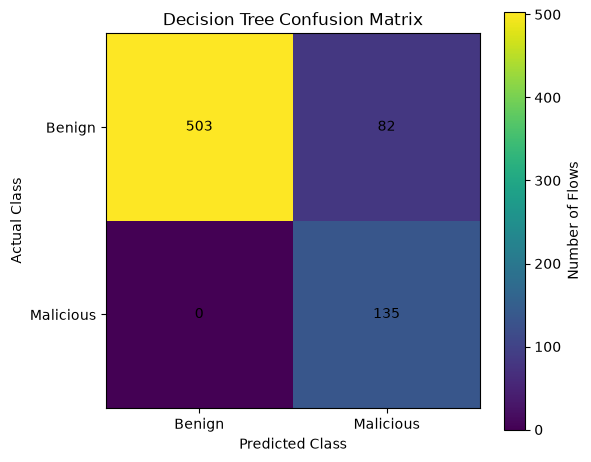

In [45]:
# D2 - Visualise the confusion matrix

fig, ax = plt.subplots(figsize=(6, 5))

image = ax.imshow(cm)

ax.set_title("Decision Tree Confusion Matrix")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Benign", "Malicious"])

ax.set_yticks([0, 1])
ax.set_yticklabels(["Benign", "Malicious"])

# Display the counts inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(image, ax=ax, label="Number of Flows")
plt.tight_layout()
plt.show()

In [46]:
# D3 - Score the unlabelled investigation network flows

X_investigation = flow_investigation[features].copy()

# Generate probability that each flow is malicious
malicious_class_index = list(decision_tree.classes_).index(1)

flow_investigation["malicious_probability"] = (
    decision_tree.predict_proba(X_investigation)[:, malicious_class_index]
)

# Generate predicted class using the model's default threshold
flow_investigation["predicted_label"] = (
    decision_tree.predict(X_investigation)
)

print("Investigation flows scored successfully.")
print(f"Total flows scored: {len(flow_investigation)}")

print("\nPredicted class counts:")
print(flow_investigation["predicted_label"].value_counts())

Investigation flows scored successfully.
Total flows scored: 466

Predicted class counts:
predicted_label
0    379
1     87
Name: count, dtype: int64


In [47]:
# D3 - Identify the top 10 highest-scoring investigation flows

top_10 = (
    flow_investigation
    .sort_values(
        by="malicious_probability",
        ascending=False
    )
    .head(10)
    .copy()
)

top_10[
    [
        "flow_id",
        "timestamp",
        "src_ip",
        "dst_ip",
        "dst_port",
        "protocol",
        "duration_sec",
        "src_bytes",
        "dst_bytes",
        "packets",
        "connections_2s",
        "serror_rate",
        "rerror_rate",
        "same_srv_rate",
        "diff_srv_rate",
        "malicious_probability",
        "predicted_label"
    ]
]

,flow_id,timestamp,src_ip,dst_ip,dst_port,protocol,duration_sec,src_bytes,dst_bytes,packets,connections_2s,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,malicious_probability,predicted_label
322,CASE-SCAN-01,2026-08-15 00:18:00,10.14.7.23,10.20.5.12,1433,TCP,0.195,76,29,1,50,0.8188,0.1632,0.0962,0.9436,1.000000,1
323,CASE-SCAN-05,2026-08-15 00:18:28,10.14.7.23,10.20.3.50,443,TCP,0.368,71,28,4,68,0.7336,0.2757,0.1816,0.8653,1.000000,1
327,CASE-SCAN-06,2026-08-15 01:18:35,10.14.7.23,10.20.2.15,25,TCP,0.350,69,53,3,31,0.6168,0.2424,0.0932,0.7410,1.000000,1
337,CASE-SCAN-02,2026-08-15 02:18:07,10.14.7.23,10.20.8.20,445,TCP,0.259,103,25,2,62,0.6770,0.2864,0.2635,0.7105,1.000000,1
338,CASE-SCAN-03,2026-08-15 02:18:14,10.14.7.23,10.20.9.10,443,TCP,0.543,162,25,3,46,0.6557,0.0664,0.1800,0.7012,1.000000,1
339,CASE-SCAN-04,2026-08-15 02:18:21,10.14.7.23,10.20.1.10,389,TCP,0.240,65,3,3,36,0.7441,0.1764,0.3058,0.7609,1.000000,1
83,INV00102,2026-08-11 04:49:45,10.14.7.23,13.107.6.156,445,TCP,6.667,958,2768,3,1,0.0560,0.0332,0.8207,0.1768,0.834427,1
437,INV00137,2026-08-16 12:26:03,10.14.7.23,44.236.72.93,443,TCP,8.479,4637,1024,5,5,0.0192,0.0083,0.9665,0.0512,0.834427,1
84,INV00138,2026-08-11 04:53:30,10.14.7.23,44.236.72.93,80,TCP,14.510,11717,2657,10,7,0.0280,0.0599,0.9157,0.1132,0.834427,1
62,INV00017,2026-08-10 22:49:05,10.14.9.18,20.112.52.29,22,TCP,34.386,37313,959,27,3,0.0510,0.0749,0.8676,0.2039,0.834427,1


In [48]:
# D3 - Compare model results with the log-based exfiltration finding

exfil_model_check = flow_investigation[
    (flow_investigation["src_ip"] == "10.14.7.23") &
    (flow_investigation["dst_ip"] == "45.77.89.11")
].copy()

exfil_model_check[
    [
        "flow_id",
        "timestamp",
        "src_ip",
        "dst_ip",
        "dst_port",
        "src_bytes",
        "dst_bytes",
        "connections_2s",
        "serror_rate",
        "rerror_rate",
        "same_srv_rate",
        "diff_srv_rate",
        "malicious_probability",
        "predicted_label"
    ]
].sort_values("malicious_probability", ascending=False)

,flow_id,timestamp,src_ip,dst_ip,dst_port,src_bytes,dst_bytes,connections_2s,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,malicious_probability,predicted_label
324,CASE-EXFIL-04,2026-08-15 00:44:06,10.14.7.23,45.77.89.11,443,25220702,8724,2,0.0,0.0,0.9423,0.0579,0.834427,1
326,CASE-EXFIL-16,2026-08-15 00:56:13,10.14.7.23,45.77.89.11,443,18937274,15624,1,0.0,0.0,0.9820,0.0109,0.834427,1
329,CASE-EXFIL-02,2026-08-15 01:42:17,10.14.7.23,45.77.89.11,443,22956668,9652,4,0.0,0.0,0.9676,0.0583,0.834427,1
330,CASE-EXFIL-06,2026-08-15 01:46:00,10.14.7.23,45.77.89.11,443,18232892,20968,1,0.0,0.0,0.9282,0.0493,0.834427,1
331,CASE-EXFIL-08,2026-08-15 01:48:16,10.14.7.23,45.77.89.11,443,25051197,12255,3,0.0,0.0,0.9939,0.0358,0.834427,1
333,CASE-EXFIL-13,2026-08-15 01:53:06,10.14.7.23,45.77.89.11,443,24395175,16896,2,0.0,0.0,0.9814,0.0539,0.834427,1
347,CASE-EXFIL-05,2026-08-15 02:45:02,10.14.7.23,45.77.89.11,443,27541671,11606,4,0.0,0.0,0.9244,0.0163,0.834427,1
348,CASE-EXFIL-07,2026-08-15 02:47:02,10.14.7.23,45.77.89.11,443,19481487,30941,4,0.0,0.0,0.9863,0.0328,0.834427,1
349,CASE-EXFIL-10,2026-08-15 02:50:10,10.14.7.23,45.77.89.11,443,27377693,17163,2,0.0,0.0,0.9611,0.0342,0.834427,1
350,CASE-EXFIL-11,2026-08-15 02:51:16,10.14.7.23,45.77.89.11,443,21598435,31055,4,0.0,0.0,0.9397,0.0375,0.834427,1


In [49]:
# D3 - Prepare required top 10 suspicious flows output

top_10_output = top_10[
    [
        "flow_id",
        "timestamp",
        "src_ip",
        "dst_ip",
        "malicious_probability"
    ]
].copy()

# Rename columns to match the submission requirement
top_10_output = top_10_output.rename(columns={
    "src_ip": "source",
    "dst_ip": "destination",
    "malicious_probability": "probability_score"
})

# Add cautious interpretations
def interpret_flow(row):
    if str(row["flow_id"]).startswith("CASE-SCAN"):
        return (
            "Very high-scoring flow consistent with internal "
            "discovery/probing activity identified in firewall evidence."
        )
    else:
        return (
            "High-scoring model result requiring correlation with "
            "authentication, DNS and firewall evidence before classification."
        )

top_10_output["interpretation"] = top_10_output.apply(
    interpret_flow,
    axis=1
)

top_10_output

,flow_id,timestamp,source,destination,probability_score,interpretation
322,CASE-SCAN-01,2026-08-15 00:18:00,10.14.7.23,10.20.5.12,1.000000,Very high-scoring flow consistent with interna...
323,CASE-SCAN-05,2026-08-15 00:18:28,10.14.7.23,10.20.3.50,1.000000,Very high-scoring flow consistent with interna...
327,CASE-SCAN-06,2026-08-15 01:18:35,10.14.7.23,10.20.2.15,1.000000,Very high-scoring flow consistent with interna...
337,CASE-SCAN-02,2026-08-15 02:18:07,10.14.7.23,10.20.8.20,1.000000,Very high-scoring flow consistent with interna...
338,CASE-SCAN-03,2026-08-15 02:18:14,10.14.7.23,10.20.9.10,1.000000,Very high-scoring flow consistent with interna...
339,CASE-SCAN-04,2026-08-15 02:18:21,10.14.7.23,10.20.1.10,1.000000,Very high-scoring flow consistent with interna...
83,INV00102,2026-08-11 04:49:45,10.14.7.23,13.107.6.156,0.834427,High-scoring model result requiring correlatio...
437,INV00137,2026-08-16 12:26:03,10.14.7.23,44.236.72.93,0.834427,High-scoring model result requiring correlatio...
84,INV00138,2026-08-11 04:53:30,10.14.7.23,44.236.72.93,0.834427,High-scoring model result requiring correlatio...
62,INV00017,2026-08-10 22:49:05,10.14.9.18,20.112.52.29,0.834427,High-scoring model result requiring correlatio...


In [50]:
# D3 - Export required model output

output_path = Path("outputs") / "top_10_suspicious_flows.csv"

top_10_output.to_csv(
    output_path,
    index=False
)

print(f"Saved successfully: {output_path}")

Saved successfully: outputs\top_10_suspicious_flows.csv


In [51]:
# Reproducibility - software and library versions

import sys
import pandas as pd
import matplotlib
import sklearn

print(f"Python version: {sys.version.split()[0]}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")

Python version: 3.14.0
pandas version: 3.0.5
matplotlib version: 3.11.1
scikit-learn version: 1.9.0
